# 03 — Modelo econométrico final e Inefficiency Score

## Release v1.0.0 — Scouting Intelligence Platform

## Objetivo del notebook

Este notebook desarrolla el modelo econométrico final del proyecto y muestra cómo transformar predicciones de valor de mercado en una primera señal de ineficiencia.

En la release v1.0.0 el proyecto ya no se limita a estimar valor de mercado, sino que separa explícitamente:

```text
Historical Evaluation Layer
↓
Current Scouting Layer
↓
Player Intelligence Layer
↓
Decision Support Layer
```

Por tanto, este notebook pertenece principalmente a la **Historical Evaluation Layer**.

Su función es:

- construir un benchmark econométrico interpretable;
- estimar el valor esperado de mercado;
- analizar drivers estructurales de valoración;
- generar un Inefficiency Score exploratorio sobre test histórico;
- servir como referencia metodológica frente al pipeline productivo de Machine Learning.

La generación operativa de shortlists actuales en la release v1.0.0 se realiza posteriormente mediante:

```text
Tuned XGBoost
↓
Scoring Engine
↓
Risk Framework
↓
Current Scouting Layer
↓
Player Intelligence Layer
```


## 1. Objetivo analítico y decisión de negocio

El objetivo econométrico es estimar el valor de mercado esperado de un jugador joven a partir de:

- edad;
- volumen competitivo;
- producción ofensiva;
- contexto de liga;
- posición;
- variables de rendimiento disponibles.

Desde el punto de vista de negocio, el objetivo no es únicamente minimizar error predictivo, sino construir una referencia interpretable que permita detectar discrepancias entre valor observado y valor esperado.

Estas discrepancias alimentan una primera noción de:

```text
ineficiencia de mercado
```

No obstante, en la arquitectura v1.0.0, el modelo econométrico se interpreta como benchmark explicativo. Las recomendaciones operativas actuales se generan en la capa de Machine Learning y Scouting Intelligence.


## 2. Especificación econométrica

La especificación base estima:

```python
log_market_value_eur ~
age +
log_minutes_played +
goals_per90 +
assists_per90 +
league FE +
position FE
```

Decisión metodológica v1.0.0:

- se mantiene `log_market_value_eur` como target principal;
- se utilizan efectos fijos de liga y posición;
- se evita que el modelo final dependa de efectos fijos de temporada para predecir temporadas futuras;
- la temporada se conserva como variable descriptiva y de split temporal;
- la evaluación se realiza con validación temporal estricta.

Esta decisión es coherente con Sprint 10, donde la temporada 2025-2026 se reserva para la capa operativa de scouting actual.


In [1]:
# ============================================================
# 1. Imports y configuración
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

TARGET = "log_market_value_eur"
RANDOM_STATE = 42

TRAIN_SEASONS = [
    "2019-2020",
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
]

TEST_SEASON = "2024-2025"
CURRENT_SCOUTING_SEASON = "2025-2026"


In [2]:
# ============================================================
# 2. Rutas del proyecto
# ============================================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "player_season_modeling.parquet"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"
MODEL_OUTPUT_DIR = OUTPUT_DIR / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

PROJECT_ROOT: c:\Users\manue\Projects\market-value-football-tfm
DATA_PATH: c:\Users\manue\Projects\market-value-football-tfm\data\processed\player_season_modeling.parquet
OUTPUT_DIR: c:\Users\manue\Projects\market-value-football-tfm\data\outputs


## 3. Carga y validación del dataset modelizable

El dataset modelizable procede de:

```text
data/processed/player_season_modeling.parquet
```

En la release v1.0.0 debe contener la cobertura completa:

```text
2019-2020 → 2025-2026
```

Este notebook utiliza únicamente las temporadas históricas para la validación econométrica y deja 2025-2026 fuera del entrenamiento/test, al pertenecer a la Current Scouting Layer.


In [3]:
# ============================================================
# 3. Carga del dataset
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No existe {DATA_PATH}. Ejecuta antes src.data.build_modeling_dataset."
    )

df = pd.read_parquet(DATA_PATH)

print("Dataset cargado")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Players: {df['player_name_fbref'].nunique() if 'player_name_fbref' in df.columns else 'n/a'}")
print(f"Seasons: {df['season'].min()} - {df['season'].max()}")
df.head()

Dataset cargado
Rows: 3,916
Columns: 54
Players: 2136
Seasons: 2019-2020 - 2025-2026


,player_name_fbref,club,league,season,season_start_year_fbref,position,position_group,age_fbref,matches_played,starts,minutes_played,nineties,goals,assists,g_a,goals_minus_pk,penalties_scored,penalties_attempted,yellow_cards,red_cards,goals_per90,assists_per90,g_a_per90,goals_minus_pk_per90,g_a_minus_pk_per90,player_name_norm,player_id_tm,player_name_tm,season_start_year_tm,valuation_date,market_value_eur,log_market_value_eur,market_value_prev_eur,market_value_next_eur,market_value_growth_1y,delta_log_market_value_1y,age_tm,date_of_birth,nationality,position_tm,sub_position_tm,foot,height_in_cm,current_club_name_tm,current_club_id_tm,competition_id_tm,source,matching_method,matching_confidence,age_diff,club_score,matching_status,season_start_year,age
0,Marvin Young,Sparta Rotterdam,Eredivisie,2025-2026,2025,DF,DEF,19.0000,33,33,2970,33.0000,0,1,1,0,0,0,7,0,0.0000,0.0300,0.0300,0.0000,0.0300,marvin young,"928,592.0000",Marvin Young,"2,025.0000",2025-10-02,"4,000,000.0000",15.2018,"2,500,000.0000","4,000,000.0000",0.0000,0.0000,20.0000,2005-10-02 00:00:00,Netherlands,Defender,Centre-Back,right,182.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.0000,100.0000,True,2025,20.0000
1,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2022-2023,2022,MF,MID,20.0000,34,29,2651,29.5000,4,2,6,4,0,0,2,0,0.1400,0.0700,0.2000,0.1400,0.2000,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,022.0000",2022-11-11,"1,200,000.0000",13.9978,"800,000.0000","3,000,000.0000",1.5000,0.9163,21.2731,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2731,100.0000,True,2022,21.2731
2,Teden Mengi,Luton Town,Premier League,2023-2024,2023,DF,DEF,21.0000,30,28,2469,27.4000,1,0,1,1,0,0,3,0,0.0400,0.0000,0.0400,0.0400,0.0400,teden mengi,"548,470.0000",Teden Mengi,"2,023.0000",2023-12-19,"7,000,000.0000",15.7614,"2,000,000.0000","12,000,000.0000",0.7143,0.5390,21.6372,2002-04-30 00:00:00,England,Defender,Centre-Back,right,186.0000,Luton Town,"1,031.0000",GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.6372,100.0000,True,2023,21.6372
3,Shurandy Sambo,Sparta Rotterdam,Eredivisie,2022-2023,2022,DF,DEF,20.0000,30,28,2307,25.6000,2,1,3,2,0,0,4,2,0.0800,0.0400,0.1200,0.0800,0.1200,shurandy sambo,"412,937.0000",Shurandy Sambo,"2,022.0000",2022-11-11,"700,000.0000",13.4588,"500,000.0000","3,000,000.0000",3.2857,1.4553,21.2293,2001-08-19 00:00:00,Curacao,Defender,Right-Back,right,174.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2293,100.0000,True,2022,21.2293
4,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2023-2024,2023,MF,MID,21.0000,24,24,2106,23.4000,5,2,7,3,2,2,2,0,0.2100,0.0900,0.3000,0.1300,0.2100,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,023.0000",2023-12-15,"4,500,000.0000",15.3196,"4,500,000.0000","4,500,000.0000",0.0000,0.0000,22.3655,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.3655,100.0000,True,2023,22.3655


In [4]:
# ============================================================
# 4. Normalización de columnas auxiliares
# ============================================================

model_df = df.copy()

# Nombre de jugador para rankings
if "player_name" not in model_df.columns:
    if "player_name_fbref" in model_df.columns:
        model_df["player_name"] = model_df["player_name_fbref"]
    elif "player_name_tm" in model_df.columns:
        model_df["player_name"] = model_df["player_name_tm"]

# Edad consolidada
if "age" not in model_df.columns:
    if "age_tm" in model_df.columns:
        model_df["age"] = model_df["age_tm"]
    elif "age_fbref" in model_df.columns:
        model_df["age"] = model_df["age_fbref"]

# Log de minutos
if "minutes_played" not in model_df.columns:
    raise KeyError("Falta minutes_played, variable mínima para el modelo.")

model_df["log_minutes_played"] = np.log1p(model_df["minutes_played"])

required = [TARGET, "market_value_eur", "season", "league", "position_group", "age", "log_minutes_played"]
missing = [c for c in required if c not in model_df.columns]
if missing:
    raise KeyError(f"Faltan columnas obligatorias: {missing}")

print("Columnas mínimas validadas correctamente")

Columnas mínimas validadas correctamente


## 4. Feature engineering deportivo

Se incorporan variables deportivas disponibles en el dataset. Cuando existen métricas suficientes, se construyen índices normalizados por `position_group` y `league` para mejorar comparabilidad entre roles y contextos competitivos.

La lógica es conservadora: no se fuerza ninguna variable inexistente. El notebook detecta columnas disponibles y ajusta la especificación final automáticamente.

In [5]:
# ============================================================
# 5. Feature engineering robusto según columnas disponibles
# ============================================================

PERFORMANCE_CANDIDATES = [
    "goals_per90",
    "assists_per90",
    "shots_per90",
    "progressive_passes_per90",
    "progressive_carries_per90",
    "tackles_per90",
    "interceptions_per90",
]

available_perf = [c for c in PERFORMANCE_CANDIDATES if c in model_df.columns]
print("Variables deportivas disponibles:", available_perf)

for col in available_perf:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")


def safe_zscore(s: pd.Series) -> pd.Series:
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / std

# Z-scores por posición y liga para controlar comparabilidad contextual
for col in available_perf:
    z_col = f"z_{col}"
    model_df[z_col] = (
        model_df
        .groupby(["position_group", "league"], dropna=False)[col]
        .transform(safe_zscore)
    )

# Índices interpretables, solo si existen los componentes necesarios
if {"z_goals_per90", "z_shots_per90"}.issubset(model_df.columns):
    model_df["finishing_index"] = model_df[["z_goals_per90", "z_shots_per90"]].mean(axis=1)

if {"z_assists_per90", "z_progressive_passes_per90"}.issubset(model_df.columns):
    model_df["playmaking_index"] = model_df[["z_assists_per90", "z_progressive_passes_per90"]].mean(axis=1)

if {"z_progressive_passes_per90", "z_progressive_carries_per90"}.issubset(model_df.columns):
    model_df["progression_index"] = model_df[["z_progressive_passes_per90", "z_progressive_carries_per90"]].mean(axis=1)

if {"z_tackles_per90", "z_interceptions_per90"}.issubset(model_df.columns):
    model_df["defensive_index"] = model_df[["z_tackles_per90", "z_interceptions_per90"]].mean(axis=1)

created_indexes = [c for c in ["finishing_index", "playmaking_index", "progression_index", "defensive_index"] if c in model_df.columns]
print("Índices creados:", created_indexes)

Variables deportivas disponibles: ['goals_per90', 'assists_per90']
Índices creados: []


## 5.1 Nota metodológica sobre features avanzadas

El notebook crea índices interpretables únicamente cuando las columnas necesarias existen en el dataset.

Esto evita romper la reproducibilidad cuando determinadas métricas avanzadas aún no forman parte del pipeline operativo.

Sprint 10.2 documenta precisamente esta limitación mediante la auditoría de métricas avanzadas de FBref, dejando su integración completa para el futuro Advanced Football Radar.


## 5. Split temporal train/test

La partición temporal se define de forma explícita para evitar incoherencias con Sprint 10:

```text
Train:
2019-2020 → 2023-2024

Test histórico:
2024-2025

Current Scouting Layer:
2025-2026
```

La temporada 2025-2026 queda excluida del entrenamiento y de la evaluación del modelo econométrico en este notebook.

Esto evita mezclar:

```text
evaluación histórica
```

con

```text
scouting operativo actual
```


In [6]:
# ============================================================
# 6. Muestra econométrica y split temporal
# ============================================================

BASE_NUMERIC_FEATURES = [
    "age",
    "log_minutes_played",
]

# Mantener producción ofensiva directa si está disponible
for c in ["goals_per90", "assists_per90"]:
    if c in model_df.columns:
        BASE_NUMERIC_FEATURES.append(c)

ADVANCED_FEATURES = [
    c for c in ["finishing_index", "playmaking_index", "progression_index", "defensive_index"]
    if c in model_df.columns
]

FINAL_NUMERIC_FEATURES = BASE_NUMERIC_FEATURES + ADVANCED_FEATURES

# En el modelo predictivo final se evitan season fixed effects porque
# una temporada futura no está observada durante el entrenamiento.
CATEGORICAL_FEATURES = ["league", "position_group"]

needed = [TARGET, "market_value_eur", "season"] + FINAL_NUMERIC_FEATURES + CATEGORICAL_FEATURES
model_df = model_df.dropna(subset=needed).copy()

train = model_df[model_df["season"].isin(TRAIN_SEASONS)].copy()
test = model_df[model_df["season"] == TEST_SEASON].copy()
current_scouting = model_df[model_df["season"] == CURRENT_SCOUTING_SEASON].copy()

if train.empty or test.empty:
    raise ValueError("El split temporal ha generado train o test vacío. Revisa las etiquetas de temporada.")

print("Features finales:", FINAL_NUMERIC_FEATURES)
print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(f"Current scouting rows: {len(current_scouting):,}")

print("Train seasons:", sorted(train["season"].unique()))
print("Test seasons:", sorted(test["season"].unique()))
print("Current scouting season:", sorted(current_scouting["season"].unique()))


Features finales: ['age', 'log_minutes_played', 'goals_per90', 'assists_per90']
Train rows: 2,745
Test rows: 552
Current scouting rows: 619
Train seasons: ['2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024']
Test seasons: ['2024-2025']
Current scouting season: ['2025-2026']


In [7]:
# Descriptivo de la muestra final
summary_sample = pd.DataFrame({
    "rows": [len(model_df)],
    "players": [model_df["player_name"].nunique() if "player_name" in model_df.columns else np.nan],
    "train_rows": [len(train)],
    "test_rows": [len(test)],
    "n_leagues": [model_df["league"].nunique()],
    "n_seasons": [model_df["season"].nunique()],
})
summary_sample

,rows,players,train_rows,test_rows,n_leagues,n_seasons
0,3916,2136,2745,552,7,7


## 6. Funciones de modelización y evaluación

Se construyen matrices de diseño consistentes entre train y test. Las dummies del test se alinean con las columnas del train para evitar errores cuando alguna categoría no aparece en una partición.

In [8]:
# ============================================================
# 7. Funciones auxiliares
# ============================================================

def build_X(data: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]) -> pd.DataFrame:
    X = data[numeric_features + categorical_features].copy()
    X = pd.get_dummies(X, columns=categorical_features, drop_first=True, dtype=float)
    X = sm.add_constant(X, has_constant="add")
    return X.astype(float)


def align_X(X_new: pd.DataFrame, X_train: pd.DataFrame) -> pd.DataFrame:
    return X_new.reindex(columns=X_train.columns, fill_value=0.0).astype(float)


def fit_ols_hc3(train_df: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]):
    X_train = build_X(train_df, numeric_features, categorical_features)
    y_train = train_df[TARGET].astype(float)
    fitted = sm.OLS(y_train, X_train).fit(cov_type="HC3")
    return fitted, X_train


def predict_with_design(fitted, data: pd.DataFrame, X_train: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]) -> np.ndarray:
    X_new = build_X(data, numeric_features, categorical_features)
    X_new = align_X(X_new, X_train)
    return fitted.predict(X_new)


def regression_metrics(y_true, y_pred, model_name: str, split: str) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "model": model_name,
        "split": split,
        "n": len(y_true),
        "MAE_log": mean_absolute_error(y_true, y_pred),
        "RMSE_log": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan,
    }

## 7. Modelos estimados

Se estiman tres modelos econométricos principales y un benchmark ingenuo:

- **M0 — Media de train**.
- **M1 — Modelo base sin efectos fijos**.
- **M2 — Modelo base con efectos fijos de liga y posición**.
- **M3 — Modelo final con variables avanzadas disponibles y efectos fijos de liga y posición**.

La variable `season` se utiliza para el split temporal, pero no como efecto fijo en el modelo final predictivo para evitar dependencia de categorías temporales no observadas en temporadas futuras.


In [9]:
# ============================================================
# 8. Estimación de modelos
# ============================================================

models = {}
metrics = []

# M0: media de train
m0_pred_train = np.repeat(train[TARGET].mean(), len(train))
m0_pred_test = np.repeat(train[TARGET].mean(), len(test))
metrics.append(regression_metrics(train[TARGET], m0_pred_train, "M0_mean_train", "train"))
metrics.append(regression_metrics(test[TARGET], m0_pred_test, "M0_mean_train", "test"))

# M1: base sin FE
m1_features = BASE_NUMERIC_FEATURES
m1, X1_train = fit_ols_hc3(train, m1_features, [])
models["M1_base_no_FE"] = (m1, X1_train, m1_features, [])

# M2: base + FE
m2, X2_train = fit_ols_hc3(train, BASE_NUMERIC_FEATURES, CATEGORICAL_FEATURES)
models["M2_base_FE"] = (m2, X2_train, BASE_NUMERIC_FEATURES, CATEGORICAL_FEATURES)

# M3: final + advanced features + FE
m3, X3_train = fit_ols_hc3(train, FINAL_NUMERIC_FEATURES, CATEGORICAL_FEATURES)
models["M3_final_FE_advanced"] = (m3, X3_train, FINAL_NUMERIC_FEATURES, CATEGORICAL_FEATURES)

for name, (fitted, Xtr, num_feats, cat_feats) in models.items():
    pred_train = predict_with_design(fitted, train, Xtr, num_feats, cat_feats)
    pred_test = predict_with_design(fitted, test, Xtr, num_feats, cat_feats)
    metrics.append(regression_metrics(train[TARGET], pred_train, name, "train"))
    metrics.append(regression_metrics(test[TARGET], pred_test, name, "test"))

metrics_df = pd.DataFrame(metrics).sort_values(["split", "RMSE_log"])
metrics_df.to_csv(OUTPUT_DIR / "03_econometric_model_metrics.csv", index=False)
metrics_df

,model,split,n,MAE_log,RMSE_log,R2
5,M2_base_FE,test,552,0.7947,0.9887,0.4366
7,M3_final_FE_advanced,test,552,0.7947,0.9887,0.4366
3,M1_base_no_FE,test,552,1.0036,1.2165,0.1472
1,M0_mean_train,test,552,1.0899,1.3212,-0.0059
4,M2_base_FE,train,2745,0.8199,1.0098,0.4074
6,M3_final_FE_advanced,train,2745,0.8199,1.0098,0.4074
2,M1_base_no_FE,train,2745,1.0146,1.2186,0.1369
0,M0_mean_train,train,2745,1.0960,1.3117,0.0000


## 8. Modelo econométrico final

El modelo seleccionado en este notebook es:

```text
M3_final_FE_advanced
```

Su papel dentro del proyecto es actuar como:

```text
benchmark econométrico interpretable
```

No sustituye al modelo productivo de la plataforma, que en la release v1.0.0 es Tuned XGBoost.


In [10]:
# ============================================================
# 9. Resumen del modelo final
# ============================================================

final_model_name = "M3_final_FE_advanced"
final_model, X_final_train, final_numeric_features, final_categorical_features = models[final_model_name]

print(final_model.summary())

                             OLS Regression Results                             
Dep. Variable:     log_market_value_eur   R-squared:                       0.407
Model:                              OLS   Adj. R-squared:                  0.405
Method:                   Least Squares   F-statistic:                     166.8
Date:                  Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                          22:43:50   Log-Likelihood:                -3921.7
No. Observations:                  2745   AIC:                             7871.
Df Residuals:                      2731   BIC:                             7954.
Df Model:                            13                                         
Covariance Type:                    HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const     

In [11]:
# Tabla de coeficientes
coef_table = pd.DataFrame({
    "term": final_model.params.index,
    "coef": final_model.params.values,
    "std_err_HC3": final_model.bse.values,
    "t": final_model.tvalues.values,
    "p_value": final_model.pvalues.values,
})
coef_table["significant_5pct"] = coef_table["p_value"] < 0.05
coef_table.to_csv(OUTPUT_DIR / "03_econometric_model_coefficients.csv", index=False)
coef_table.sort_values("p_value").head(30)

,term,coef,std_err_HC3,t,p_value,significant_5pct
0,const,10.6369,0.3982,26.7131,0.0000,True
5,league_Eredivisie,-1.4501,0.0716,-20.2609,0.0000,True
2,log_minutes_played,0.5457,0.0330,16.5509,0.0000,True
7,league_Liga Portugal,-1.1283,0.0825,-13.6723,0.0000,True
3,goals_per90,1.4069,0.1298,10.8407,0.0000,True
9,league_Premier League,0.7071,0.0705,10.0241,0.0000,True
4,assists_per90,1.7853,0.1830,9.7529,0.0000,True
8,league_Ligue 1,-0.3430,0.0710,-4.8317,0.0000,True
1,age,0.0418,0.0170,2.4593,0.0139,True
10,league_Serie A,-0.1508,0.0735,-2.0512,0.0403,True


In [12]:
# Coeficientes principales en variables deportivas/demográficas
main_terms = ["age", "log_minutes_played", "goals_per90", "assists_per90"] + ADVANCED_FEATURES
coef_table[coef_table["term"].isin(main_terms)].sort_values("term")

,term,coef,std_err_HC3,t,p_value,significant_5pct
1,age,0.0418,0.0170,2.4593,0.0139,True
4,assists_per90,1.7853,0.1830,9.7529,0.0000,True
3,goals_per90,1.4069,0.1298,10.8407,0.0000,True
2,log_minutes_played,0.5457,0.0330,16.5509,0.0000,True


## 9. Diagnóstico de multicolinealidad

El VIF se calcula sobre variables continuas centradas/escaladas y dummies de efectos fijos. Esto evita que la escala de edad o minutos infle artificialmente el diagnóstico.

In [13]:
# ============================================================
# 10. VIF con continuas estandarizadas
# ============================================================

vif_df_source = train[final_numeric_features + final_categorical_features].copy()

for col in final_numeric_features:
    mean = vif_df_source[col].mean()
    std = vif_df_source[col].std(ddof=0)
    vif_df_source[col] = 0.0 if std == 0 or pd.isna(std) else (vif_df_source[col] - mean) / std

X_vif = pd.get_dummies(vif_df_source, columns=final_categorical_features, drop_first=True, dtype=float)
X_vif = sm.add_constant(X_vif, has_constant="add")

vif_rows = []
for i, col in enumerate(X_vif.columns):
    if col == "const":
        continue
    try:
        vif_rows.append({"variable": col, "VIF": variance_inflation_factor(X_vif.values, i)})
    except Exception:
        vif_rows.append({"variable": col, "VIF": np.nan})

vif_table = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
vif_table.to_csv(OUTPUT_DIR / "03_vif_table.csv", index=False)
vif_table.head(25)

,variable,VIF
10,position_group_DEF,3.7911
12,position_group_MID,3.2610
7,league_Ligue 1,2.0177
4,league_Eredivisie,1.9162
9,league_Serie A,1.8514
8,league_Premier League,1.8020
5,league_LaLiga,1.6486
6,league_Liga Portugal,1.6099
2,goals_per90,1.4711
11,position_group_GK,1.4211


## 10. Predicción out-of-sample y residuos

Las predicciones generadas en este notebook se utilizan para evaluar el comportamiento del modelo econométrico en el test histórico 2024-2025.

El Inefficiency Score calculado aquí tiene carácter exploratorio y metodológico.

La shortlist operativa actual no se genera desde este notebook, sino desde el pipeline productivo:

```text
artifacts/predictions/tuned_xgboost_predictions.csv
↓
reports/rankings/scouting_shortlist_with_risk.csv
```


In [14]:
# ============================================================
# 11. Predicciones train/test y residuos
# ============================================================

def add_predictions(data: pd.DataFrame, split_name: str) -> pd.DataFrame:
    out = data.copy()
    out["split"] = split_name
    out["predicted_log_market_value"] = predict_with_design(
        final_model,
        out,
        X_final_train,
        final_numeric_features,
        final_categorical_features,
    )
    out["predicted_market_value_eur"] = np.exp(out["predicted_log_market_value"])
    out["residual_log_observed_minus_predicted"] = out[TARGET] - out["predicted_log_market_value"]
    out["inefficiency_score"] = out["predicted_log_market_value"] - out[TARGET]
    out["market_value_gap_eur"] = out["predicted_market_value_eur"] - out["market_value_eur"]
    out["market_value_gap_pct"] = out["market_value_gap_eur"] / out["market_value_eur"]
    return out

train_scored = add_predictions(train, "train")
test_scored = add_predictions(test, "test")
scored = pd.concat([train_scored, test_scored], ignore_index=True)

# Score estandarizado usando distribución de train para evitar leakage
score_mean = train_scored["inefficiency_score"].mean()
score_std = train_scored["inefficiency_score"].std(ddof=0)
scored["inefficiency_score_z"] = (scored["inefficiency_score"] - score_mean) / score_std if score_std > 0 else 0.0

# Confidence Score preliminar basado en matching_confidence si existe
if "matching_confidence" in scored.columns:
    scored["confidence_score"] = pd.to_numeric(scored["matching_confidence"], errors="coerce").fillna(0.5)
else:
    scored["confidence_score"] = 1.0

scored["opportunity_score"] = scored["inefficiency_score_z"] * scored["confidence_score"]

scored[["split", TARGET, "predicted_log_market_value", "inefficiency_score", "market_value_gap_eur", "opportunity_score"]].head()

,split,log_market_value_eur,predicted_log_market_value,inefficiency_score,market_value_gap_eur,opportunity_score
0,train,13.9978,14.6911,0.6932,"1,200,214.3535",0.6865
1,train,15.7614,16.5948,0.8334,"9,107,290.3169",0.8253
2,train,13.4588,14.5112,1.0524,"1,305,085.7602",1.0422
3,train,15.3196,14.7454,-0.5742,"-1,965,807.5841",-0.5686
4,train,15.8950,16.4332,0.5383,"5,704,610.3443",0.5331


In [15]:
# Métricas finales del modelo seleccionado
final_metrics = []
for split_name, d in [("train", train_scored), ("test", test_scored)]:
    final_metrics.append(regression_metrics(d[TARGET], d["predicted_log_market_value"], final_model_name, split_name))
final_metrics_df = pd.DataFrame(final_metrics)
final_metrics_df

,model,split,n,MAE_log,RMSE_log,R2
0,M3_final_FE_advanced,train,2745,0.8199,1.0098,0.4074
1,M3_final_FE_advanced,test,552,0.7947,0.9887,0.4366


In [16]:
# Exportación de predicciones
scored.to_parquet(OUTPUT_DIR / "03_econometric_scored_player_seasons.parquet", index=False)
test_scored.to_parquet(OUTPUT_DIR / "03_econometric_test_predictions.parquet", index=False)

print(f"Predicciones exportadas a {OUTPUT_DIR}")

Predicciones exportadas a c:\Users\manue\Projects\market-value-football-tfm\data\outputs


## 11. Visualizaciones de diagnóstico

Se revisan tres gráficos básicos:

1. Observado vs predicho en test.
2. Distribución de residuos en test.
3. Residuos frente a predicción en test.

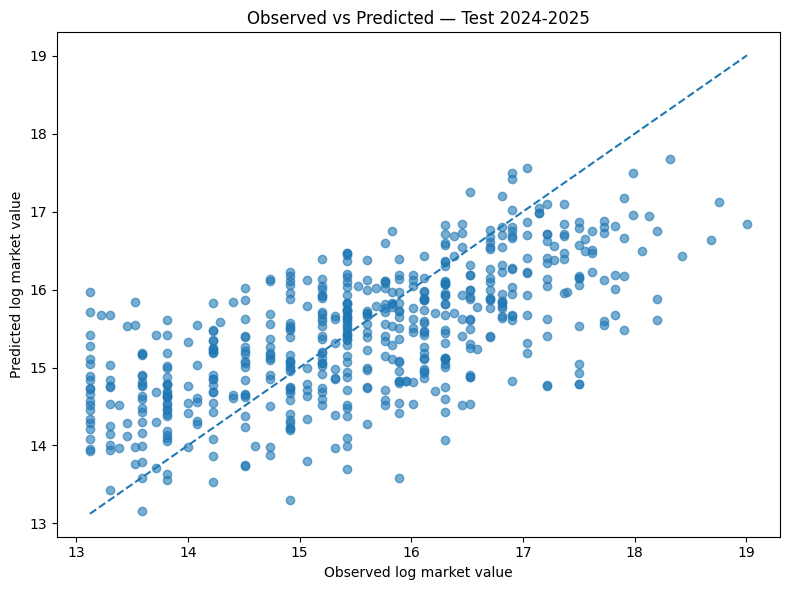

In [17]:
# Observado vs predicho en test
plt.figure(figsize=(8, 6))
plt.scatter(test_scored[TARGET], test_scored["predicted_log_market_value"], alpha=0.6)
min_val = min(test_scored[TARGET].min(), test_scored["predicted_log_market_value"].min())
max_val = max(test_scored[TARGET].max(), test_scored["predicted_log_market_value"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Observed log market value")
plt.ylabel("Predicted log market value")
plt.title("Observed vs Predicted — Test 2024-2025")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_observed_vs_predicted_test.png", dpi=150)
plt.show()

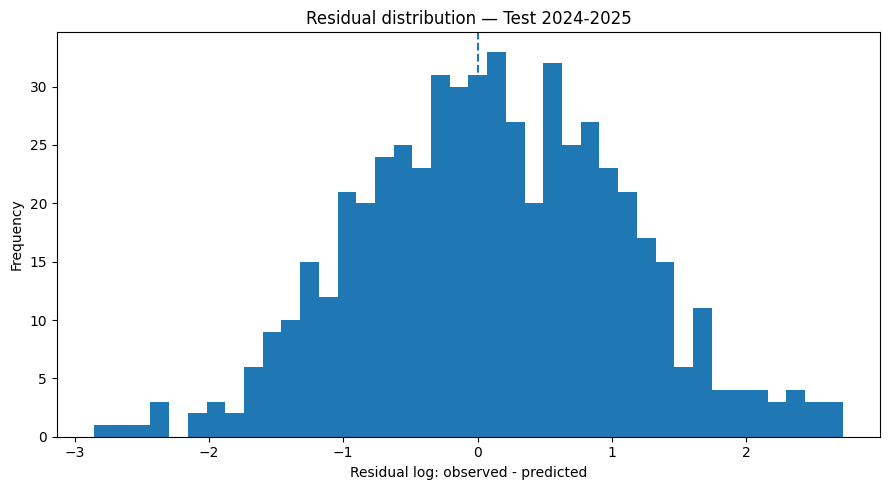

In [18]:
# Distribución de residuos en test
plt.figure(figsize=(9, 5))
plt.hist(test_scored["residual_log_observed_minus_predicted"], bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual log: observed - predicted")
plt.ylabel("Frequency")
plt.title("Residual distribution — Test 2024-2025")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_residual_distribution_test.png", dpi=150)
plt.show()

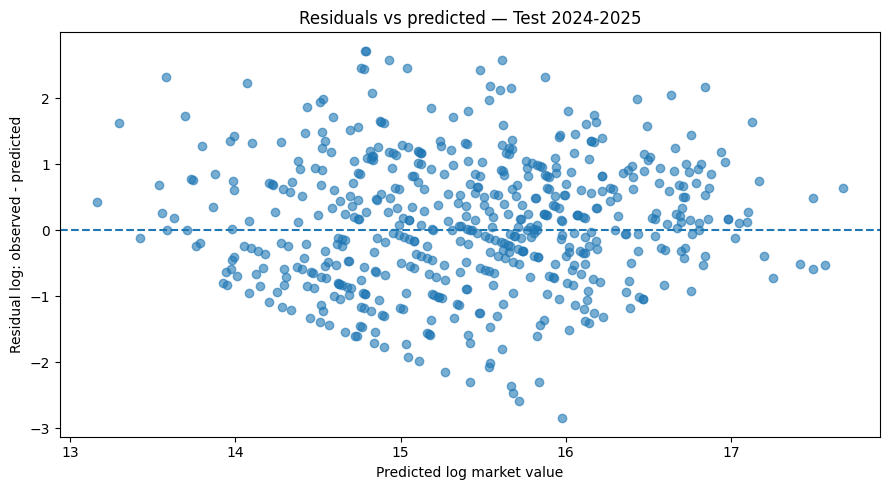

In [19]:
# Residuos vs predicción en test
plt.figure(figsize=(9, 5))
plt.scatter(test_scored["predicted_log_market_value"], test_scored["residual_log_observed_minus_predicted"], alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log market value")
plt.ylabel("Residual log: observed - predicted")
plt.title("Residuals vs predicted — Test 2024-2025")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_residuals_vs_predicted_test.png", dpi=150)
plt.show()

## 12. Inefficiency Score final

El Inefficiency Score se define como:

```text
valor estimado - valor observado
```

En este notebook se calcula sobre el test histórico para evaluar si el modelo econométrico genera señales razonables de infravaloración.

En la release v1.0.0, el scoring operativo incorpora además:

- Growth Score;
- Confidence Score;
- Opportunity Score;
- Risk Score;
- Risk-adjusted Opportunity Score.

Por tanto, el score de este notebook debe interpretarse como antecedente metodológico del Scoring Engine completo.


In [20]:
# ============================================================
# 12. Rankings sobre test out-of-sample
# ============================================================

test_scored_final = scored[scored["split"] == "test"].copy()

ranking_cols = [c for c in [
    "player_id_tm", "player_id", "player_name", "club", "current_club_name_tm",
    "league", "season", "position_group", "age", "minutes_played",
    "market_value_eur", "predicted_market_value_eur",
    "market_value_gap_eur", "market_value_gap_pct",
    "log_market_value_eur", "predicted_log_market_value",
    "inefficiency_score", "inefficiency_score_z",
    "confidence_score", "opportunity_score",
    "matching_method", "matching_confidence", "age_diff", "club_score",
] if c in test_scored_final.columns]

undervalued_ranking = (
    test_scored_final
    .query("inefficiency_score > 0")
    .sort_values(["opportunity_score", "market_value_gap_eur"], ascending=False)
    [ranking_cols]
    .head(50)
    .copy()
)

overvalued_ranking = (
    test_scored_final
    .query("inefficiency_score < 0")
    .sort_values(["opportunity_score", "market_value_gap_eur"], ascending=True)
    [ranking_cols]
    .head(50)
    .copy()
)

undervalued_ranking.to_csv(OUTPUT_DIR / "03_undervalued_ranking.csv", index=False)
overvalued_ranking.to_csv(OUTPUT_DIR / "03_overvalued_ranking.csv", index=False)

display(undervalued_ranking.head(20))

,player_id_tm,player_name,club,current_club_name_tm,league,season,position_group,age,minutes_played,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,log_market_value_eur,predicted_log_market_value,inefficiency_score,inefficiency_score_z,confidence_score,opportunity_score,matching_method,matching_confidence,age_diff,club_score
2747,"512,352.0000",Lasse Rosenboom,Holstein Kiel,Holstein Kiel,Bundesliga,2024-2025,MID,22.9185,1734,"500,000.0000","8,672,743.1908","8,172,743.1908",16.3455,13.1224,15.9757,2.8533,2.8257,1.0000,2.8257,exact_age_club_validated,1.0000,0.9185,100.0000
3185,"948,273.0000",Mario Martín,Valladolid,Getafe Club de Fútbol S. A. D. Team Dubai,LaLiga,2024-2025,MID,20.6023,1748,"500,000.0000","6,698,864.4637","6,198,864.4637",12.3977,13.1224,15.7174,2.5951,2.5699,0.8500,2.1844,exact_age_validated,0.8500,0.6023,20.8333
3054,"610,608.0000",Dominik Javorček,Holstein Kiel,"SK Slavia Praha, a.s.",Bundesliga,2024-2025,DEF,22.1328,386,"550,000.0000","6,450,374.9916","5,900,374.9916",10.7280,13.2177,15.6796,2.4620,2.4381,0.8500,2.0724,exact_age_validated,0.8500,1.1328,31.2500
2999,"1,390,649.0000",Yan Diomandé,Leganés,RasenBallsport Leipzig,LaLiga,2024-2025,MID,18.4723,545,"600,000.0000","6,398,324.3303","5,798,324.3303",9.6639,13.3047,15.6715,2.3669,2.3439,0.8500,1.9923,exact_age_validated,0.8500,1.4723,41.3793
2880,"927,353.0000",Johan Manzambi,Freiburg,Sport-Club Freiburg,Bundesliga,2024-2025,MID,18.9870,335,"750,000.0000","7,556,446.0305","6,806,446.0305",9.0753,13.5278,15.8379,2.3101,2.2877,0.8500,1.9445,exact_age_validated,0.8500,0.9870,59.2593
3042,"807,688.0000",Yassin Belkhdim,Angers,Angers Sporting Club de l'Ouest,Ligue 1,2024-2025,MID,22.6448,1523,"500,000.0000","4,989,476.7977","4,489,476.7977",8.9790,13.1224,15.4228,2.3005,2.2782,0.8500,1.9364,exact_age_validated,0.8500,0.6448,32.4324
2966,"1,061,336.0000",Pau Navarro,Villarreal,Villarreal Club de Fútbol S.A.D.,LaLiga,2024-2025,DEF,19.6496,916,"500,000.0000","4,289,660.0359","3,789,660.0359",7.5793,13.1224,15.2717,2.1494,2.1285,0.8500,1.8092,exact_age_validated,0.8500,0.6496,48.7805
3214,"1,190,411.0000",Jesus Rodríguez,Real Betis,Calcio Como,LaLiga,2024-2025,MID,18.8966,1111,"700,000.0000","5,580,619.2191","4,880,619.2191",6.9723,13.4588,15.5348,2.0760,2.0558,0.8500,1.7475,exact_age_validated,0.8500,0.8966,19.0476
2883,"917,375.0000",Antoine Hainaut,Parma,Parma Calcio 1913,Serie A,2024-2025,DEF,22.6639,1206,"750,000.0000","5,631,034.5205","4,881,034.5205",6.5080,13.5278,15.5438,2.0160,1.9964,0.8500,1.6970,exact_age_validated,0.8500,0.6639,58.8235
3050,"743,496.0000",Kévin Danois,Auxerre,Association de la Jeunesse auxerroise,Ligue 1,2024-2025,MID,20.2765,1460,"500,000.0000","3,646,390.8582","3,146,390.8582",6.2928,13.1224,15.1092,1.9869,1.9676,0.8500,1.6725,exact_age_validated,0.8500,0.2765,31.8182


In [21]:
print("Top overvalued players — test")
display(overvalued_ranking.head(20))

Top overvalued players — test


,player_id_tm,player_name,club,current_club_name_tm,league,season,position_group,age,minutes_played,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,log_market_value_eur,predicted_log_market_value,inefficiency_score,inefficiency_score_z,confidence_score,opportunity_score,matching_method,matching_confidence,age_diff,club_score
2783,"810,092.0000",Warren Zaïre-Emery,Paris Saint-Germain,Paris Saint-Germain Football Club,Ligue 1,2024-2025,DEF,18.7598,2050,"60,000,000.0000","5,302,297.5761","-54,697,702.4239",-0.9116,17.9099,15.4837,-2.4262,-2.4027,1.0000,-2.4027,exact_age_club_validated,1.0000,0.7598,73.0769
2969,"650,568.0000",António Silva,Benfica,Sport Lisboa e Benfica,Liga Portugal,2024-2025,DEF,20.9418,2037,"40,000,000.0000","2,639,418.6041","-37,360,581.3959",-0.9340,17.5044,14.7861,-2.7183,-2.6920,0.8500,-2.2882,exact_age_validated,0.8500,0.9418,48.2759
2870,"974,982.0000",Ousmane Diomande,Sporting CP,Sporting Clube de Portugal,Liga Portugal,2024-2025,DEF,21.0431,2521,"40,000,000.0000","2,644,857.2222","-37,355,142.7778",-0.9339,17.5044,14.7881,-2.7163,-2.6899,0.8500,-2.2864,exact_age_validated,0.8500,1.0431,59.4595
2868,"646,740.0000",Gavi,Barcelona,Futbol Club Barcelona,LaLiga,2024-2025,MID,20.3943,1085,"80,000,000.0000","6,045,272.1645","-73,954,727.8355",-0.9244,18.1975,15.6148,-2.5828,-2.5577,0.8500,-2.1740,exact_age_validated,0.8500,1.3943,60.0000
3252,"565,424.0000",Johan Bakayoko,PSV,RasenBallsport Leipzig,Eredivisie,2024-2025,MID,21.6619,1579,"40,000,000.0000","3,040,064.0554","-36,959,935.9446",-0.9240,17.5044,14.9274,-2.5770,-2.5520,0.8500,-2.1692,exact_age_validated,0.8500,0.6619,16.0000
2765,"792,380.0000",Aleksandar Pavlovic,Bayern Munich,FC Bayern München,Bundesliga,2024-2025,MID,20.4353,1451,"50,000,000.0000","5,609,003.2396","-44,390,996.7604",-0.8878,17.7275,15.5399,-2.1876,-2.1664,1.0000,-2.1664,exact_age_club_validated,1.0000,0.4353,80.0000
2787,"616,341.0000",Nuno Mendes,Paris Saint-Germain,Paris Saint-Germain Football Club,Ligue 1,2024-2025,DEF,22.4778,1676,"55,000,000.0000","6,377,455.1072","-48,622,544.8928",-0.8840,17.8228,15.6683,-2.1546,-2.1337,1.0000,-2.1337,exact_age_club_validated,1.0000,0.4778,73.0769
3101,"971,570.0000",Endrick,Real Madrid,Olympique Lyonnais,LaLiga,2024-2025,ATT,18.4367,363,"40,000,000.0000","3,409,352.4759","-36,590,647.5241",-0.9148,17.5044,15.0420,-2.4624,-2.4385,0.8500,-2.0727,exact_age_validated,0.8500,0.4367,27.5862
3251,"904,802.0000",Jorrel Hato,Ajax,Chelsea Football Club,Eredivisie,2024-2025,DEF,18.7817,2588,"30,000,000.0000","2,574,020.5824","-27,425,979.4176",-0.9142,17.2167,14.7610,-2.4557,-2.4319,0.8500,-2.0671,exact_age_validated,0.8500,0.7817,16.0000
3289,"473,169.0000",Brian Brobbey,Ajax,Sunderland Association Football Club,Eredivisie,2024-2025,ATT,22.8747,1555,"30,000,000.0000","2,627,379.4814","-27,372,620.5186",-0.9124,17.2167,14.7815,-2.4352,-2.4116,0.8500,-2.0499,exact_age_validated,0.8500,0.8747,10.0000


## 13. Análisis agregado del score

El análisis agregado permite comprobar si las señales de ineficiencia presentan patrones coherentes por:

- liga;
- posición;
- nivel de confianza;
- valor de mercado.

Estas lecturas son útiles para diagnóstico econométrico, pero no reemplazan la capa operativa de ranking introducida posteriormente.


In [22]:
# Asegurar que el subset de test incluye todas las columnas de scoring
test_scored_final = scored[scored["split"] == "test"].copy()

# Inefficiency por liga en test
league_score = (
    test_scored_final
    .groupby("league", dropna=False)
    .agg(
        n=("inefficiency_score", "size"),
        mean_inefficiency=("inefficiency_score", "mean"),
        median_inefficiency=("inefficiency_score", "median"),
        mean_gap_eur=("market_value_gap_eur", "mean"),
        median_gap_eur=("market_value_gap_eur", "median"),
        mean_gap_pct=("market_value_gap_pct", "mean"),
        mean_confidence=("confidence_score", "mean"),
        mean_opportunity=("opportunity_score", "mean"),
    )
    .reset_index()
    .sort_values("mean_inefficiency", ascending=False)
)

display(league_score)

league_score.to_csv(
    OUTPUT_DIR / "03_inefficiency_by_league_test.csv",
    index=False
)

,league,n,mean_inefficiency,median_inefficiency,mean_gap_eur,median_gap_eur,mean_gap_pct,mean_confidence,mean_opportunity
2,LaLiga,72,0.1280,0.1877,"-7,566,536.4340","873,522.6618",1.0175,0.8604,0.1098
6,Serie A,77,-0.0350,-0.0079,"-2,243,924.9540","-53,940.3606",0.3978,0.8539,-0.0293
3,Liga Portugal,60,-0.0831,0.1704,"-2,587,369.3970","297,934.8336",0.4453,0.8525,-0.0700
0,Bundesliga,77,-0.1143,-0.1972,"-7,782,837.6081","-1,733,088.5173",0.6015,0.8792,-0.0982
1,Eredivisie,93,-0.1351,-0.0800,"-2,184,488.4382","-226,326.2838",0.3210,0.8629,-0.1052
4,Ligue 1,99,-0.1513,-0.1657,"-4,973,238.4160","-1,139,686.2941",0.4342,0.8682,-0.1410
5,Premier League,74,-0.3548,-0.3321,"-9,947,333.1825","-7,429,290.2188",-0.0867,0.8723,-0.3109


In [23]:
# Re-crear subsets después de calcular todos los scores
train_scored = scored[scored["split"] == "train"].copy()
test_scored = scored[scored["split"] == "test"].copy()

required_scoring_cols = [
    "inefficiency_score",
    "inefficiency_score_z",
    "confidence_score",
    "opportunity_score",
]

missing_cols = [c for c in required_scoring_cols if c not in test_scored.columns]

if missing_cols:
    raise KeyError(f"Missing scoring columns in test_scored: {missing_cols}")

print("Scoring subsets actualizados correctamente")
print(f"Train scored: {train_scored.shape}")
print(f"Test scored: {test_scored.shape}")

Scoring subsets actualizados correctamente
Train scored: (2745, 68)
Test scored: (552, 68)


## 14. Robustness check con matching estricto

Este robustness check evalúa si los resultados son sensibles a la calidad del matching.

Se restringe la muestra a observaciones con mayor confianza de integración.

Interpretación:

- si la muestra estricta mantiene resultados similares, aumenta la confianza metodológica;
- si mejora sustancialmente, puede indicar que el ruido de matching penaliza el modelo;
- si empeora, puede reflejar pérdida de cobertura o sesgo de selección.

En Sprint 10, esta lógica se complementa con Confidence Score y Risk Score dentro de la Current Scouting Layer.


In [24]:
# ============================================================
# 13. Robustness check: matching estricto
# ============================================================

strict_df = model_df.copy()

if "matching_confidence" in strict_df.columns:
    strict_df = strict_df[pd.to_numeric(strict_df["matching_confidence"], errors="coerce") >= 0.99]

if "age_diff" in strict_df.columns:
    strict_df = strict_df[pd.to_numeric(strict_df["age_diff"], errors="coerce") <= 1.0]

if "matching_method" in strict_df.columns:
    strict_df = strict_df[strict_df["matching_method"].isin([
        "exact_age_validated",
        "exact_age_club_validated",
        "fuzzy_age_club_validated",
    ])]

strict_train = strict_df[strict_df["season"].isin(TRAIN_SEASONS)].copy()
strict_test = strict_df[strict_df["season"] == TEST_SEASON].copy()

print(f"Strict rows: {len(strict_df):,}")
print(f"Strict train rows: {len(strict_train):,}")
print(f"Strict test rows: {len(strict_test):,}")

if len(strict_train) >= 50 and len(strict_test) >= 20:
    strict_model, X_strict_train = fit_ols_hc3(strict_train, final_numeric_features, final_categorical_features)
    strict_pred_test = predict_with_design(strict_model, strict_test, X_strict_train, final_numeric_features, final_categorical_features)
    strict_metrics = pd.DataFrame([
        regression_metrics(strict_test[TARGET], strict_pred_test, "M3_strict_matching", "test")
    ])
    display(strict_metrics)
    strict_metrics.to_csv(OUTPUT_DIR / "03_strict_matching_metrics.csv", index=False)
else:
    print("Muestra estricta demasiado pequeña para estimar un modelo robusto comparable.")


Strict rows: 189
Strict train rows: 109
Strict test rows: 40


,model,split,n,MAE_log,RMSE_log,R2
0,M3_strict_matching,test,40,0.8981,1.1346,0.4320


## 15. Conclusiones para la memoria del TFM

Este notebook consolida la capa econométrica final del proyecto y la sitúa correctamente dentro de la arquitectura v1.0.0.

La principal corrección metodológica introducida para Sprint 10 es la separación explícita entre:

```text
Historical Evaluation Layer
↓
Current Scouting Layer
```

El modelo econométrico se entrena y evalúa sobre una partición histórica:

- Train: 2019-2020 → 2023-2024.
- Test: 2024-2025.
- Current Scouting: 2025-2026, excluida de esta validación.

Conclusiones principales:

1. El modelo econométrico permite construir un benchmark interpretable para estimar valor de mercado esperado.
2. Las variables de edad, minutos, goles y asistencias mantienen coherencia futbolística y económica.
3. Los efectos de liga y posición capturan heterogeneidad estructural del mercado.
4. El Inefficiency Score econométrico permite una primera lectura de discrepancias entre valor estimado y valor observado.
5. El modelo econométrico no debe interpretarse como motor final de recomendaciones operativas actuales.
6. La capa operativa de la release v1.0.0 se apoya en Tuned XGBoost, Scoring Engine, Risk Framework y Player Intelligence Layer.

Comparación conceptual:

```text
Econometría
=
interpretabilidad + benchmark metodológico

Machine Learning
=
mejor capacidad predictiva + scoring operativo
```

La evidencia acumulada del proyecto indica que la mejora del Machine Learning frente a la econometría existe, pero es moderada. Por ello, el principal valor del sistema no reside únicamente en maximizar métricas predictivas, sino en transformar predicciones en señales accionables, interpretables y ajustadas por riesgo.

En la memoria final, este notebook debe presentarse como la transición entre:

```text
modelización explicativa
```

y

```text
scoring cuantitativo de oportunidades
```

dentro de una plataforma integral de Scouting Intelligence.


## 16. Próximos pasos

A partir de este notebook, la evolución metodológica continúa hacia:

1. **Machine Learning supervisado**  
   Evaluar si modelos no lineales mejoran el benchmark econométrico.

2. **Explainability**  
   Interpretar predicciones mediante feature importance y SHAP.

3. **Scoring Engine**  
   Transformar predicciones en Inefficiency, Growth, Confidence y Opportunity Score.

4. **Risk Framework**  
   Incorporar incertidumbre en la priorización de oportunidades.

5. **Current Scouting Layer**  
   Aplicar el modelo productivo sobre la temporada 2025-2026.

6. **Player Intelligence Layer**  
   Enriquecer rankings mediante radar, benchmarking y narrativa de scouting.

Esta evolución ya queda consolidada en la release v1.0.0.
